In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

EXTRACT

In [2]:
df=pd.read_csv("Airline_Delay_Cause.csv")

TRANSFORM

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  str    
 3   carrier_name         171666 non-null  str    
 4   airport              171666 non-null  str    
 5   airport_name         171666 non-null  str    
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay            171426 

In [4]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [5]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,171666.000000,171666.000000,171426.000000,171223.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000,171426.00000,171426.000000,171426.000000,171426.000000,171426.000000,171426.000000
mean,2018.551361,6.493633,362.528467,66.434387,20.796615,2.250347,19.381147,0.157096,23.770554,7.530497,0.863387,4239.48733,1437.185124,222.563497,920.651704,7.382725,1651.700063
std,2.890006,3.440908,992.894662,179.540694,50.315176,7.314252,61.675244,0.717405,72.393477,43.654880,3.772853,12618.56605,4215.677812,821.086511,3423.509335,41.779985,5221.878385
min,2013.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,4.000000,50.000000,6.000000,2.160000,0.000000,1.000000,0.000000,1.230000,0.000000,0.000000,335.00000,110.000000,0.000000,34.000000,0.000000,65.000000
50%,2019.000000,7.000000,100.000000,17.000000,6.400000,0.400000,3.910000,0.000000,5.000000,1.000000,0.000000,1018.00000,375.000000,18.000000,146.000000,0.000000,320.000000
75%,2021.000000,9.000000,250.000000,47.000000,17.260000,1.860000,11.710000,0.000000,15.260000,4.000000,1.000000,2884.00000,1109.000000,146.000000,477.000000,0.000000,1070.000000
max,2023.000000,12.000000,21977.000000,4176.000000,1293.910000,266.420000,1884.420000,58.690000,2069.070000,4951.000000,197.000000,438783.00000,196944.000000,31960.000000,112018.000000,3760.000000,227959.000000


In [6]:
df.shape

(171666, 21)

In [7]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64

Here I'm dropping the null rows instead of filling them with median (optimal central tendancy for this dataset since it is right skewed) because only 0.257% of the original data is being lost on removing the empty rows and since delay columns are related, filling each row with their respective median breaks the mathematical relationship of:
arr_delay = carrier_delay + weather_delay + nas_delay + security_delay + late_aircraft_delay


In [8]:
df.dropna(inplace=True)  

In [9]:
df.shape

(171223, 21)

In [10]:
df.info()

<class 'pandas.DataFrame'>
Index: 171223 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171223 non-null  int64  
 1   month                171223 non-null  int64  
 2   carrier              171223 non-null  str    
 3   carrier_name         171223 non-null  str    
 4   airport              171223 non-null  str    
 5   airport_name         171223 non-null  str    
 6   arr_flights          171223 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171223 non-null  float64
 9   weather_ct           171223 non-null  float64
 10  nas_ct               171223 non-null  float64
 11  security_ct          171223 non-null  float64
 12  late_aircraft_ct     171223 non-null  float64
 13  arr_cancelled        171223 non-null  float64
 14  arr_diverted         171223 non-null  float64
 15  arr_delay            171223 non-n

In [11]:
#converting strings to category
df['carrier']=df['carrier'].astype('category')
df['carrier_name']=df['carrier_name'].astype('category')
df['airport']=df['airport'].astype('category')
df['airport_name']=df['airport_name'].astype('category')

In [12]:
#converting counts to int-64
df['arr_flights']=df['arr_flights'].astype(int)
df['arr_del15']=df['arr_del15'].astype(int)
df['carrier_ct']=df['carrier_ct'].astype(int)
df['weather_ct']=df['weather_ct'].astype(int)
df['nas_ct'] = df['nas_ct'].astype(int)
df['security_ct'] = df['security_ct'].astype(int)
df['late_aircraft_ct'] = df['late_aircraft_ct'].astype(int)
df['arr_cancelled'] = df['arr_cancelled'].astype(int)
df['arr_diverted'] = df['arr_diverted'].astype(int)

In [13]:
df.dtypes

year                      int64
month                     int64
carrier                category
carrier_name           category
airport                category
airport_name           category
arr_flights               int64
arr_del15                 int64
carrier_ct                int64
weather_ct                int64
nas_ct                    int64
security_ct               int64
late_aircraft_ct          int64
arr_cancelled             int64
arr_diverted              int64
arr_delay               float64
carrier_delay           float64
weather_delay           float64
nas_delay               float64
security_delay          float64
late_aircraft_delay     float64
dtype: object

Feature Engineering

In [14]:
#Percentage of flights delayed more than 15 minutes
df["delay_rate"]=df['arr_del15']/df['arr_flights']

In [15]:
df["delay_rate"].describe()

count    171223.000000
mean          0.183365
std           0.110349
min           0.000000
25%           0.109890
50%           0.170732
75%           0.241528
max           1.000000
Name: delay_rate, dtype: float64

In [16]:
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89,13,2,1,...,5,2,1,1375.0,71.0,761.0,118.0,0.0,425.0,0.146067
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62,10,1,0,...,7,0,1,799.0,218.0,1.0,62.0,0.0,518.0,0.161290
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62,10,2,1,...,4,1,0,766.0,56.0,188.0,78.0,0.0,444.0,0.161290
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66,12,3,2,...,1,1,1,1397.0,471.0,320.0,388.0,0.0,218.0,0.181818
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92,22,7,0,...,11,2,0,1530.0,628.0,0.0,134.0,0.0,768.0,0.239130


In [17]:
df['arr_delay'].describe()

count    171223.000000
mean       4244.513617
std       12625.199210
min           0.000000
25%         336.000000
50%        1020.000000
75%        2888.500000
max      438783.000000
Name: arr_delay, dtype: float64

LOAD

In [18]:
df.to_csv("Cleaned_airline_delay.csv",index=False)

VISUALIZATION

In [ ]:
#Binning
bins=[0,15,60,180,df['arr_delay'].max()]
labels=['Short delay','Medium delay','Long delay','Extreme delay']
df['Delay Category']=pd.cut(df['arr_delay'],labels=labels, bins=bins, include_lowest=True) #for including 0

In [27]:
df['Delay Category'].value_counts()

Delay Category
Extreme delay    143888
Long delay        14001
Short delay        6872
Medium delay       6462
Name: count, dtype: int64

In [28]:
numeric_cols = df.select_dtypes(include=['int64','float64'])

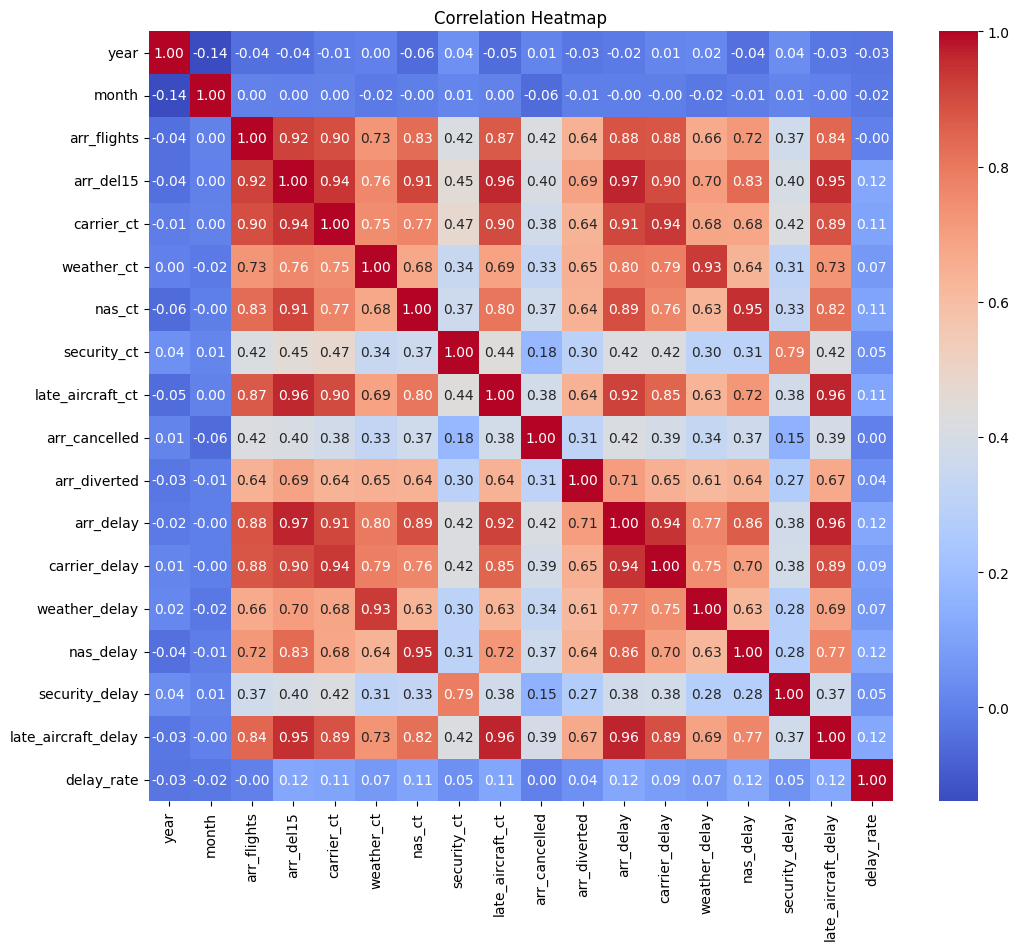

In [29]:
plt.figure(figsize=(12,10))
sns.heatmap(numeric_cols.corr(),annot=True,fmt='.2f',cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Explanation:
This is basically a heatmap generated on the basis of correlation matrix of the numeric values. The correlation values range from -1 to +1 indicating perfect negative correlation and perfect positive correlation respectively. 
Here, security_ct shows weak correlation with almost all other columns (mostly below 0.5), suggesting that security-related delays are rare and independent of other delay causes.


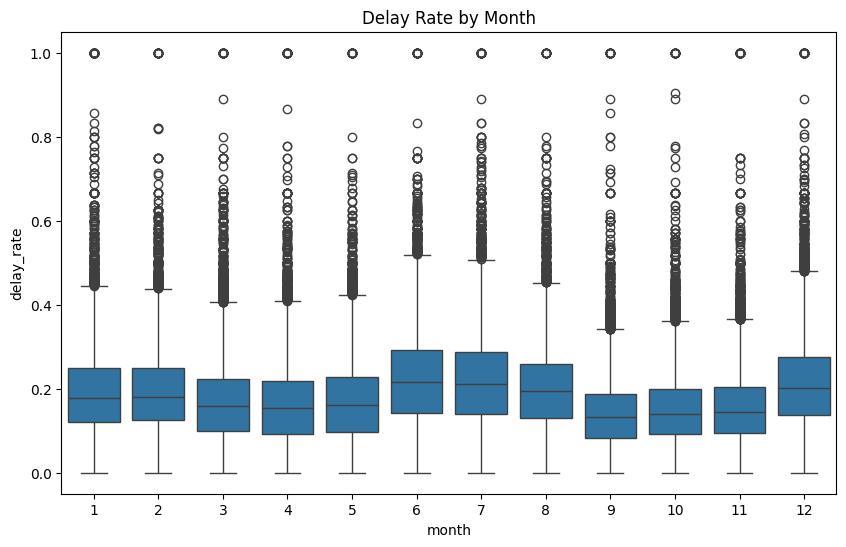

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(x='month', y='delay_rate', data=df)
plt.title('Delay Rate by Month')
plt.show()

Explanation:
A boxplot visualization showing the distribution of delay_rate across each month. The box represents the interquartile range (IQR) — the middle 50% of data, the line inside the box is the median, and the circles above are outliers. From the plot, June (6) and July (7) show the highest median delay rates, suggesting summer months experience more delays, likely due to increased air traffic and weather events. September (9) and October (10) show the lowest delay rates, indicating fall months are the best time to fly with fewer delays.

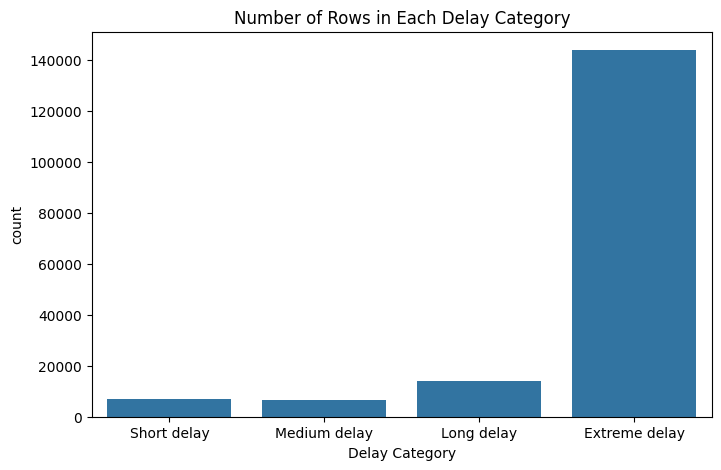

In [31]:
plt.figure(figsize=(8,5))
sns.countplot(x='Delay Category', data=df, order=labels)
plt.title('Number of Rows in Each Delay Category')
plt.show()

Explanation:
A countplot showing the number of flights in each delay category. The plot reveals that the vast majority of flights (~144,000) fall under 'Extreme delay', while 'Short delay' has the least number of flights (~287). This suggests that when flights do get delayed, they tend to be delayed by a significant amount rather than just a few minutes.

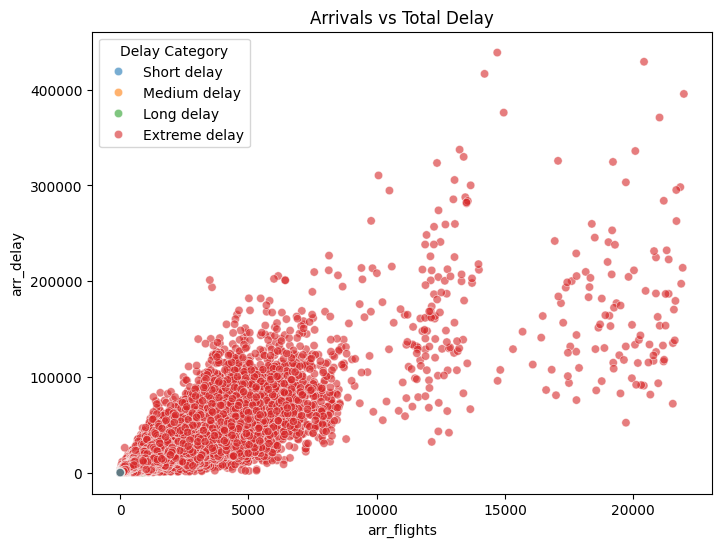

In [33]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='arr_flights', y='arr_delay', hue='Delay Category', data=df, alpha=0.6)
plt.title('Arrivals vs Total Delay')
plt.show()

Explanation:
A scatter plot showing the relationship between total arriving flights (arr_flights) and total arrival delay (arr_delay), colored by delay category. The plot clearly shows a positive relationship — as the number of arriving flights increases, the total delay also increases. This makes intuitive sense as busier airports/routes naturally accumulate more total delay minutes. Almost all points are 'Extreme delay' (red) confirming that high flight volume routes tend to have very high cumulative delays. The few 'Short delay' and 'Medium delay' points (blue/orange) are clustered near the bottom-left, representing smaller airports with low flight volumes and minimal total delays.

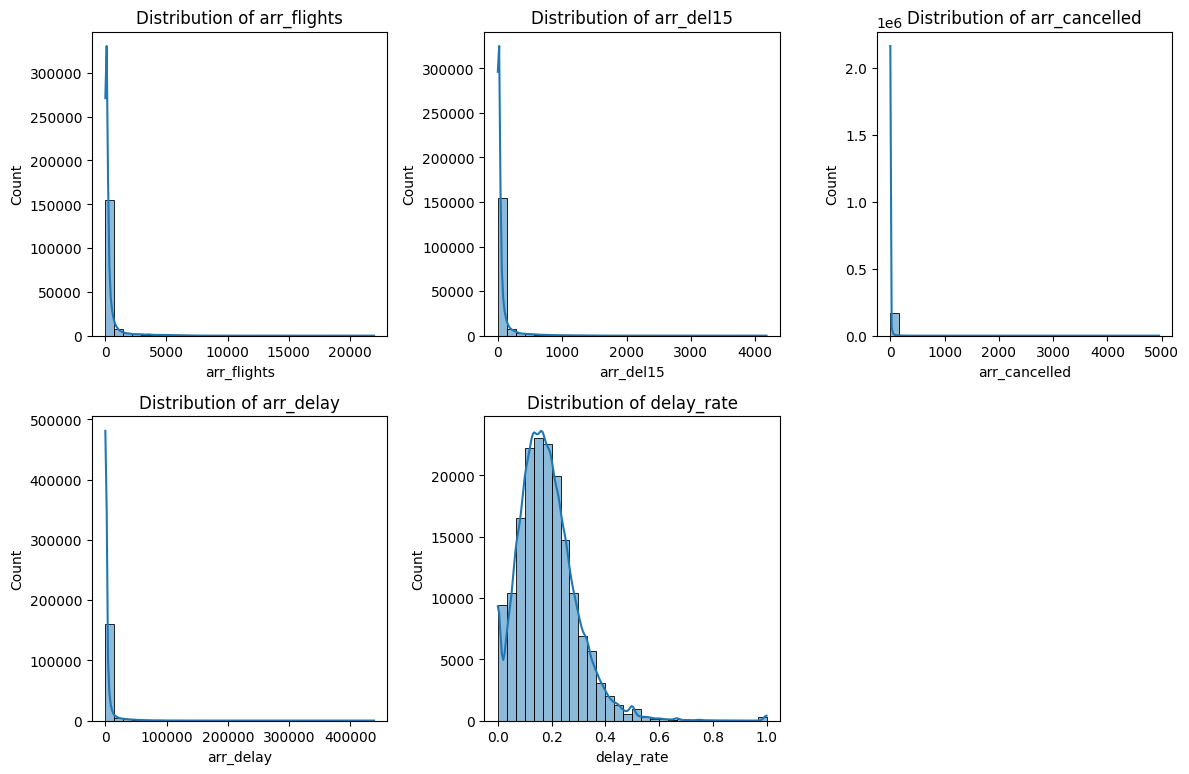

In [36]:
plt.figure(figsize=(12,8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,3,i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Explanation:
The histograms show the distribution of key numerical columns. Most columns such as arr_flights, arr_del15, arr_delay and arr_cancelled are strongly right skewed — majority of values are concentrated at the lower end with a few extreme outliers, confirming our earlier assumption. delay_rate is the exception, showing a near normal distribution centered around 0.2, meaning on average 20% of flights experience delays across all routes